In [ ]:
#Modeling
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import AgglomerativeClustering,KMeans,DBSCAN,BisectingKMeans
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score,davies_bouldin_score
from sklearn.decomposition import PCA
from scipy.cluster.hierarchy import dendrogram, linkage
import scipy.cluster.hierarchy as sch

In [ ]:
df=pd.read_csv("/content/cleaned_Global_clustering.csv")

In [ ]:
df.head(10)

,Birth Rate,CO2 Emissions,Country,Energy Usage,GDP,Health Exp % GDP,Health Exp/Capita,Infant Mortality Rate,Internet Usage,Lending Interest,Life Expectancy Female,Life Expectancy Male,Mobile Phone Usage,Population 0-14,Population 15-64,Population 65+,Population Total,Population Urban,Tourism Inbound,Tourism Outbound
0,0.020,87931.0,Algeria,26998.0,5.479006e+10,0.035,60.0,0.034,0.0,0.100,71.0,67.0,0.0,0.342,0.619,0.039,31719449,0.599,102000000.0,193000000.0
1,0.050,9542.0,Angola,7499.0,9.129595e+09,0.034,22.0,0.128,0.0,1.032,47.0,44.0,0.0,0.476,0.499,0.025,13924930,0.324,34000000.0,146000000.0
2,0.043,1617.0,Benin,1983.0,2.359122e+09,0.043,15.0,0.090,0.0,0.120,57.0,53.0,0.0,0.454,0.517,0.029,6949366,0.383,77000000.0,50000000.0
3,0.027,4276.0,Botswana,1836.0,5.788312e+09,0.047,152.0,0.054,0.0,0.155,52.0,49.0,0.1,0.383,0.587,0.029,1755375,0.532,227000000.0,209000000.0
4,0.046,1041.0,Burkina Faso,14338.0,2.610959e+09,0.051,12.0,0.096,0.0,0.120,52.0,49.0,0.0,0.468,0.505,0.028,11607944,0.178,23000000.0,30000000.0
5,0.042,301.0,Burundi,14338.0,8.704861e+08,0.063,7.0,0.092,0.0,0.158,49.0,47.0,0.0,0.490,0.481,0.029,6674286,0.082,1400000.0,14000000.0
6,0.041,3432.0,Cameroon,6310.0,9.287368e+09,0.044,26.0,0.093,0.0,0.220,53.0,51.0,0.0,0.453,0.513,0.034,15927713,0.455,132000000.0,241000000.0
7,0.039,268.0,Central African Republic,14338.0,9.145003e+08,0.043,11.0,0.113,0.0,0.220,45.0,42.0,0.0,0.423,0.537,0.040,3638316,0.376,5000000.0,33000000.0
8,0.051,176.0,Chad,14338.0,1.385058e+09,0.063,10.0,0.106,0.0,0.220,48.0,46.0,0.0,0.490,0.482,0.028,8301151,0.216,14000000.0,56000000.0
9,0.039,84.0,Comoros,14338.0,2.018999e+08,0.035,13.0,0.073,0.0,0.120,59.0,56.0,0.5,0.415,0.554,0.031,528312,0.281,15000000.0,456000000.0


In [ ]:
print("Rows, Columns:", df.shape)


print("Unique countries:", df["Country"].nunique())


country_counts = df["Country"].value_counts()
print(country_counts)

Rows, Columns: (2704, 20)
Unique countries: 208
Country
Algeria                     13
Angola                      13
Benin                       13
Botswana                    13
Burkina Faso                13
                            ..
Turks and Caicos Islands    13
United States               13
Uruguay                     13
Venezuela, RB               13
Virgin Islands (U.S.)       13
Name: count, Length: 208, dtype: int64


In [ ]:
#SCALING
country_col = df["Country"]
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns

scaler = StandardScaler()
scaled_values = scaler.fit_transform(df[numeric_cols])

scaled_df = pd.DataFrame(scaled_values, columns=numeric_cols)
final_scaled = pd.concat([country_col, scaled_df], axis=1)

final_scaled.head()

,Country,Birth Rate,CO2 Emissions,Energy Usage,GDP,Health Exp % GDP,Health Exp/Capita,Infant Mortality Rate,Internet Usage,Lending Interest,Life Expectancy Female,Life Expectancy Male,Mobile Phone Usage,Population 0-14,Population 15-64,Population 65+,Population Total,Population Urban,Tourism Inbound,Tourism Outbound
0,Algeria,-0.233864,-0.046899,-0.135363,-0.174562,-1.162045,-0.479956,0.084186,-0.908914,-0.274918,-0.033671,0.044785,-1.246165,0.384182,-0.090043,-0.683981,0.002110,0.147449,-0.328776,-0.311777
1,Angola,2.469335,-0.189777,-0.226814,-0.216569,-1.202383,-0.507102,3.355575,-0.908914,6.205386,-2.326553,-2.464476,-1.246165,1.696192,-1.882290,-0.976654,-0.141087,-0.976530,-0.334026,-0.315641
2,Benin,1.838589,-0.204222,-0.252684,-0.222797,-0.839336,-0.512102,2.033099,-0.908914,-0.135856,-1.371185,-1.482591,-1.246165,1.480788,-1.613453,-0.893033,-0.197221,-0.735385,-0.330706,-0.323534
3,Botswana,0.396882,-0.199376,-0.253374,-0.219643,-0.677982,-0.414235,0.780226,-0.908914,0.107503,-1.848869,-1.918984,-1.028797,0.785618,-0.567976,-0.893033,-0.239018,-0.126393,-0.319126,-0.310461
4,Burkina Faso,2.108909,-0.205272,-0.194739,-0.222566,-0.516628,-0.514245,2.241911,-0.908914,-0.135856,-1.848869,-1.918984,-1.246165,1.617863,-1.792677,-0.913938,-0.159732,-1.573260,-0.334875,-0.325178


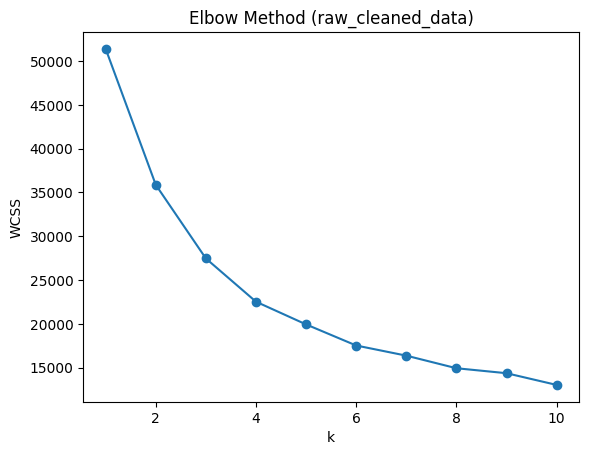

In [ ]:
# Raw cleaned data
numeric_cols_df = final_scaled.select_dtypes(include='number').columns
X_df = final_scaled[numeric_cols_df].values

# elbow method for raw data
wcss_df = []
for k in range(1, 11):
    km = KMeans(n_clusters=k, random_state=42, n_init=10).fit(X_df)
    wcss_df.append(km.inertia_)
plt.plot(range(1, 11), wcss_df, marker='o')
plt.xlabel('k'); plt.ylabel('WCSS'); plt.title('Elbow Method (raw_cleaned_data)')
plt.show()

results_df = {}

In [ ]:
# cluster names
cluster_names = {
    0: "Rising Nations",
    1: "Advanced Nations",
    2: "Global Leaders"
}


KMeans → Silhouette: 0.3517239861243839 DBI: 0.957758274945523


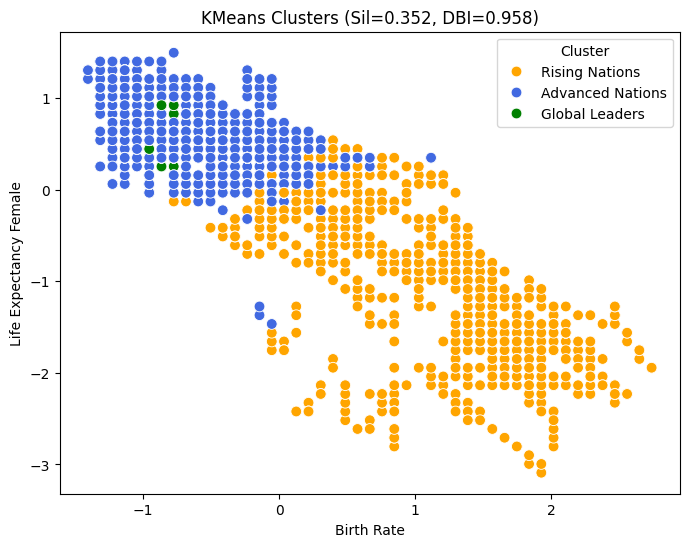

In [ ]:
# KMeans clustering
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10).fit(X_df)
final_scaled['KMeans_Cluster'] = kmeans.labels_

# Map clusters to motivational labels
final_scaled['KMeans_Label'] = final_scaled['KMeans_Cluster'].map(cluster_names)

# Evaluate metrics
results_df = {}
results_df['KMeans'] = {
    'Silhouette': silhouette_score(X_df, kmeans.labels_),
    'DBI': davies_bouldin_score(X_df, kmeans.labels_)
}
print("KMeans → Silhouette:", results_df['KMeans']['Silhouette'],
      "DBI:", results_df['KMeans']['DBI'])

# Visualization with updated labels and colors
plt.figure(figsize=(8,6))
sns.scatterplot(data=final_scaled, x='Birth Rate', y='Life Expectancy Female',
                hue='KMeans_Label',
                palette={'Rising Nations':'orange',
                         'Advanced Nations':'royalblue',
                         'Global Leaders':'green'},
                s=60)
plt.title(f'KMeans Clusters (Sil={results_df["KMeans"]["Silhouette"]:.3f}, DBI={results_df["KMeans"]["DBI"]:.3f})')
plt.legend(title="Cluster")
plt.show()


DBSCAN → Silhouette: -0.25077549192237997 DBI: 1.191900354901618


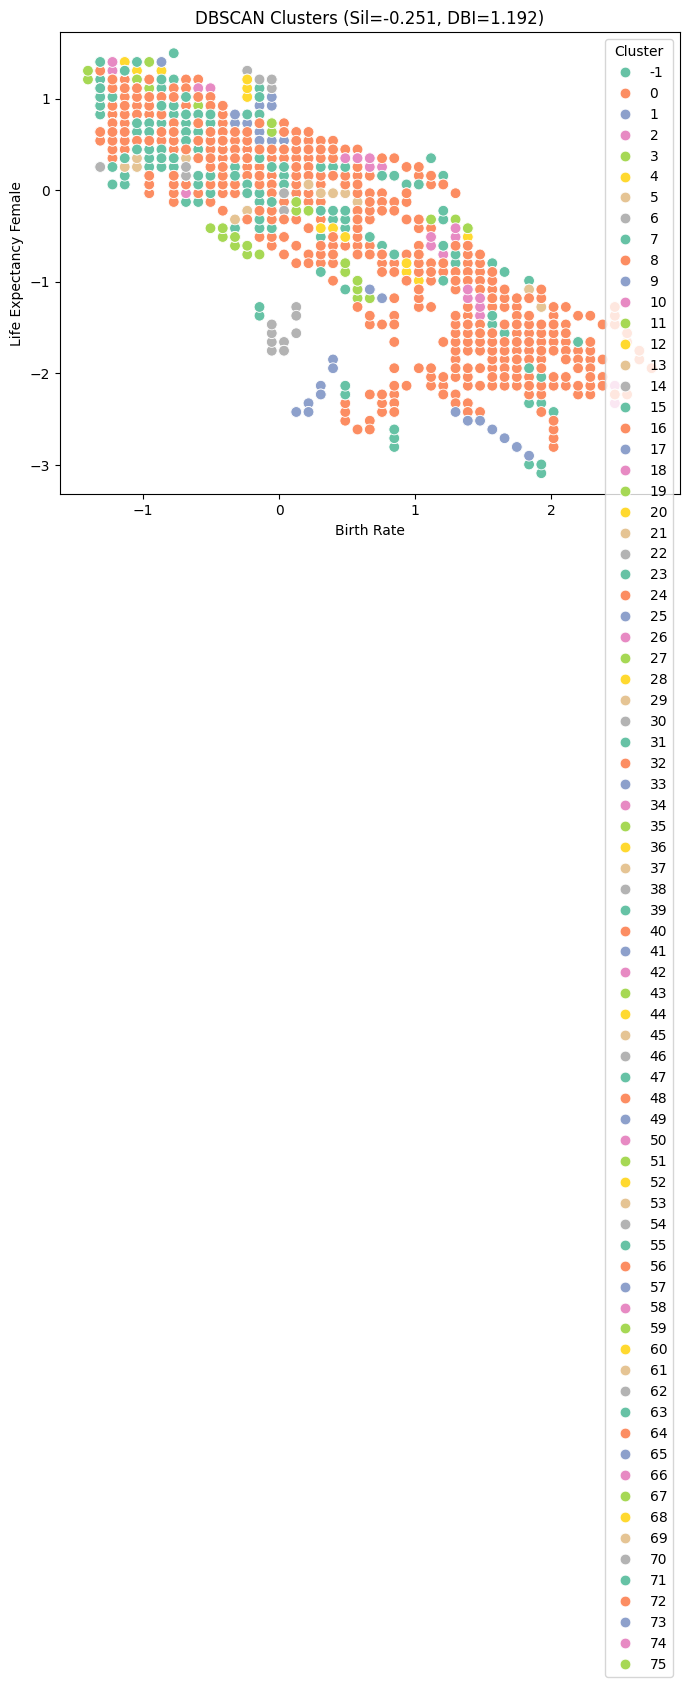

In [ ]:
# DBSCAN
db = DBSCAN(eps=1.0, min_samples=5).fit(X_df)
final_scaled['DBSCAN_Cluster'] = db.labels_
labels_db = db.labels_
valid_clusters = set(labels_db) - {-1}
if len(valid_clusters) >= 2:
    mask = labels_db != -1
    sil = silhouette_score(X_df[mask], labels_db[mask])
    dbi = davies_bouldin_score(X_df[mask], labels_db[mask])
else:
    sil, dbi = float('nan'), float('nan')
results_df['DBSCAN'] = {'Silhouette': sil, 'DBI': dbi}

print("DBSCAN → Silhouette:", results_df['DBSCAN']['Silhouette'],
      "DBI:", results_df['DBSCAN']['DBI'])



plt.figure(figsize=(8,6))
sns.scatterplot(data=final_scaled, x='Birth Rate', y='Life Expectancy Female',
                hue='DBSCAN_Cluster', palette='Set2', s=60)
plt.title(f'DBSCAN Clusters (Sil={results_df["DBSCAN"]["Silhouette"]:.3f}, DBI={results_df["DBSCAN"]["DBI"]:.3f})')
plt.legend(title="Cluster"); plt.show()

In [ ]:
cluster_counts = final_scaled['DBSCAN_Cluster'].value_counts().sort_index()
print("\nCluster counts:")
print(cluster_counts)



Cluster counts:
DBSCAN_Cluster
-1      317
 0     1700
 1       13
 2       13
 3       13
       ... 
 71       7
 72       4
 73       5
 74       6
 75       5
Name: count, Length: 77, dtype: int64


In [ ]:
# I tested DBSCAN across eps values.
# At eps = 1.0, it created one giant cluster and 75 tiny ones.
# The Silhouette score was −0.251, indicating poor cluster separation.
# This confirms DBSCAN is not suitable for segmentation.
# I’ll use KMeans as the main model for the dashboard.

Agglomerative → Silhouette: 0.3375204163297061 DBI: 1.0525067058676825


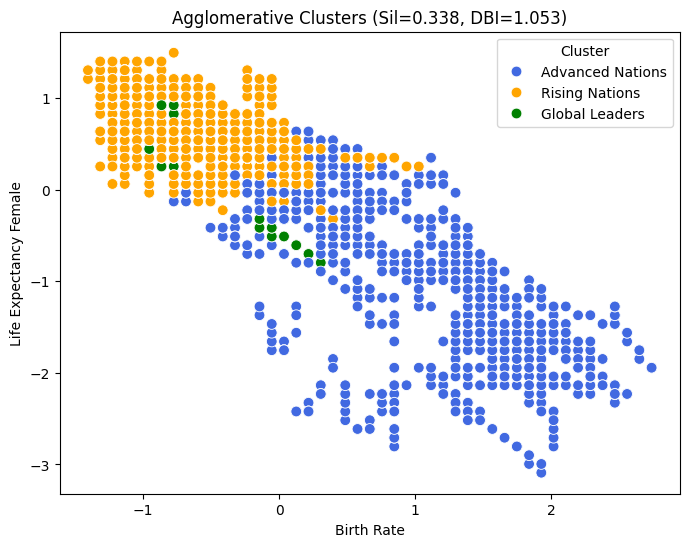

In [ ]:
# Agglomerative
agg = AgglomerativeClustering(n_clusters=3, linkage='ward').fit(X_df)
final_scaled['Agglomerative_Cluster'] = agg.labels_
final_scaled['Agglomerative_Label'] = final_scaled['Agglomerative_Cluster'].map(cluster_names)

results_df['Agglomerative'] = {
    'Silhouette': silhouette_score(X_df, agg.labels_),
    'DBI': davies_bouldin_score(X_df, agg.labels_)
}
print("Agglomerative → Silhouette:", results_df['Agglomerative']['Silhouette'],
      "DBI:", results_df['Agglomerative']['DBI'])

plt.figure(figsize=(8,6))
sns.scatterplot(data=final_scaled, x='Birth Rate', y='Life Expectancy Female',
                hue='Agglomerative_Label',
                palette={'Rising Nations':'orange',
                         'Advanced Nations':'royalblue',
                         'Global Leaders':'green'},
                s=60)
plt.title(f'Agglomerative Clusters (Sil={results_df["Agglomerative"]["Silhouette"]:.3f}, DBI={results_df["Agglomerative"]["DBI"]:.3f})')
plt.legend(title="Cluster")
plt.show()


Divisive → Silhouette: 0.35074914492926307 DBI: 1.0748092523573645


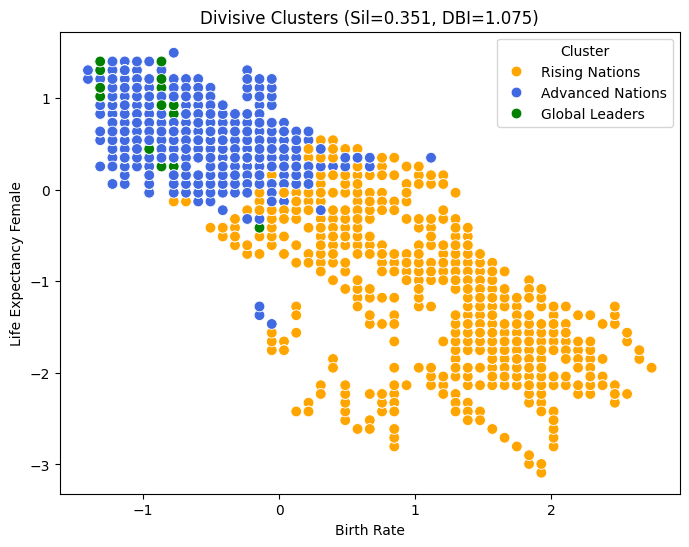

In [ ]:
# Divisive
div = BisectingKMeans(n_clusters=3, random_state=42).fit(X_df)
final_scaled['Divisive_Cluster'] = div.labels_
final_scaled['Divisive_Label'] = final_scaled['Divisive_Cluster'].map(cluster_names)

results_df['Divisive'] = {
    'Silhouette': silhouette_score(X_df, div.labels_),
    'DBI': davies_bouldin_score(X_df, div.labels_)
}
print("Divisive → Silhouette:", results_df['Divisive']['Silhouette'],
      "DBI:", results_df['Divisive']['DBI'])

plt.figure(figsize=(8,6))
sns.scatterplot(data=final_scaled, x='Birth Rate', y='Life Expectancy Female',
                hue='Divisive_Label',
                palette={'Rising Nations':'orange',
                         'Advanced Nations':'royalblue',
                         'Global Leaders':'green'},
                s=60)
plt.title(f'Divisive Clusters (Sil={results_df["Divisive"]["Silhouette"]:.3f}, DBI={results_df["Divisive"]["DBI"]:.3f})')
plt.legend(title="Cluster")
plt.show()


GaussianMixture → Silhouette: 0.2028962013125016 DBI: 1.315935434281211


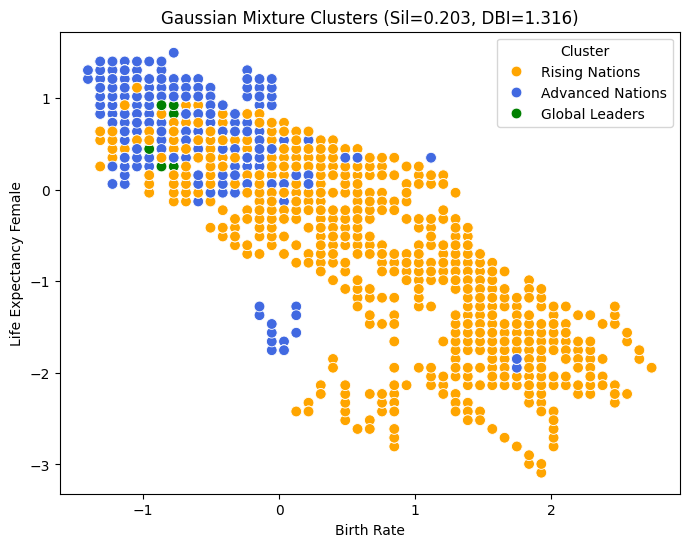

In [ ]:
# Gaussian Mixture
gm = GaussianMixture(n_components=3, random_state=42).fit(X_df)
labels_gm = gm.predict(X_df)
final_scaled['GaussianMixture_Cluster'] = labels_gm
final_scaled['GaussianMixture_Label'] = final_scaled['GaussianMixture_Cluster'].map(cluster_names)

results_df['GaussianMixture'] = {
    'Silhouette': silhouette_score(X_df, labels_gm),
    'DBI': davies_bouldin_score(X_df, labels_gm)
}
print("GaussianMixture → Silhouette:", results_df['GaussianMixture']['Silhouette'],
      "DBI:", results_df['GaussianMixture']['DBI'])

plt.figure(figsize=(8,6))
sns.scatterplot(data=final_scaled, x='Birth Rate', y='Life Expectancy Female',
                hue='GaussianMixture_Label',
                palette={'Rising Nations':'orange',
                         'Advanced Nations':'royalblue',
                         'Global Leaders':'green'},
                s=60)
plt.title(f'Gaussian Mixture Clusters (Sil={results_df["GaussianMixture"]["Silhouette"]:.3f}, DBI={results_df["GaussianMixture"]["DBI"]:.3f})')
plt.legend(title="Cluster")
plt.show()


In [ ]:
# print results
print("raw_cleaned_data  : ->")
for m in results_df:
    print(m, "Silhouette:", results_df[m]['Silhouette'], "DBI:", results_df[m]['DBI'])

raw_cleaned_data  : ->
KMeans Silhouette: 0.3517239861243839 DBI: 0.957758274945523
DBSCAN Silhouette: -0.25077549192237997 DBI: 1.191900354901618
Agglomerative Silhouette: 0.3375204163297061 DBI: 1.0525067058676825
Divisive Silhouette: 0.35074914492926307 DBI: 1.0748092523573645
GaussianMixture Silhouette: 0.2028962013125016 DBI: 1.315935434281211


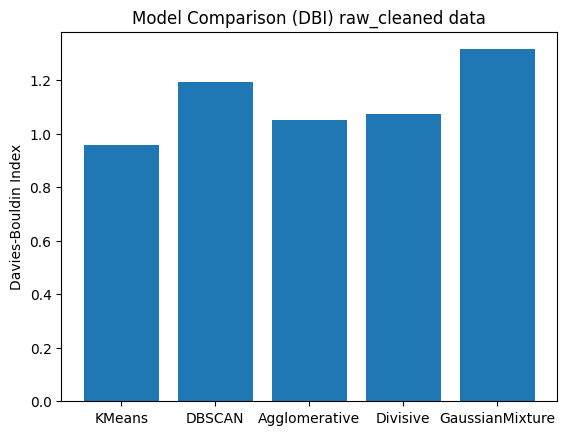

In [ ]:
# DBI comparison plot
models = list(results_df.keys())
dbi_scores = [results_df[m]['DBI'] for m in models]
plt.bar(models, dbi_scores)
plt.ylabel('Davies-Bouldin Index'); plt.title('Model Comparison (DBI) raw_cleaned data')
plt.show()

In [ ]:
# avg_countries stores average raw features per country (from original cleaned df)
avg_countries = df.groupby("Country").mean().reset_index()

In [ ]:
avg_countries.head(10)

,Country,Birth Rate,CO2 Emissions,Energy Usage,GDP,Health Exp % GDP,Health Exp/Capita,Infant Mortality Rate,Internet Usage,Lending Interest,Life Expectancy Female,Life Expectancy Male,Mobile Phone Usage,Population 0-14,Population 15-64,Population 65+,Population Total,Population Urban,Tourism Inbound,Tourism Outbound
0,Afghanistan,0.043154,3322.384615,14338.000000,1.013132e+10,0.087154,55.615385,0.082769,0.023077,0.141385,58.769231,56.384615,0.292308,0.490308,0.488769,0.020769,2.539926e+07,0.232923,4.644615e+08,3.123077e+08
1,Albania,0.014692,4613.923077,2971.769231,8.895522e+09,0.061462,168.846154,0.017769,0.192308,0.142385,79.230769,73.000000,0.561538,0.258385,0.653692,0.087923,2.956845e+06,0.478538,1.165231e+09,1.007077e+09
2,Algeria,0.022077,88328.615385,32526.461538,1.190391e+11,0.038462,133.846154,0.027769,0.069231,0.083231,71.615385,68.384615,0.492308,0.292692,0.663077,0.044231,3.476067e+07,0.645154,2.752308e+08,4.513077e+08
3,American Samoa,0.020077,8529.000000,14338.000000,1.507975e+10,0.061000,193.000000,0.020000,0.100000,0.120000,75.000000,69.000000,0.307692,0.299500,0.642500,0.052000,5.752538e+04,0.880000,6.885000e+08,4.560000e+08
4,Andorra,0.011308,1767.076923,14338.000000,6.210341e+09,0.063231,2394.461538,0.003000,0.484615,0.120000,75.000000,69.000000,0.700000,0.299500,0.642500,0.052000,7.668408e+04,0.897462,6.885000e+08,4.560000e+08
5,Angola,0.048308,17560.076923,10606.692308,5.049648e+10,0.041692,104.538462,0.118154,0.038462,0.512308,50.153846,47.384615,0.230769,0.477538,0.498154,0.024462,1.721272e+07,0.369846,2.793846e+08,2.323846e+08
6,Antigua and Barbuda,0.018385,1665.923077,9969.461538,1.043837e+09,0.046308,576.076923,0.010462,0.307692,0.111769,77.076923,72.153846,1.115385,0.276769,0.651308,0.071846,8.352338e+04,0.286308,3.373462e+08,7.507692e+07
7,Argentina,0.017615,136088.000000,64675.384615,3.352997e+11,0.084923,587.615385,0.015000,0.269231,0.166385,78.769231,71.230769,0.815385,0.260615,0.635769,0.103231,3.899545e+07,0.902385,3.987692e+09,5.057308e+09
8,Armenia,0.013769,4778.692308,3311.384615,6.380928e+09,0.049231,96.461538,0.020154,0.123077,0.200615,76.769231,69.923077,0.453846,0.221385,0.669615,0.108923,3.007292e+06,0.640308,2.740000e+08,2.917692e+08
9,Aruba,0.012077,3239.076923,14338.000000,3.291032e+09,0.061000,193.000000,0.020000,0.384615,0.112154,76.846154,72.000000,0.923077,0.215154,0.694000,0.090692,9.886608e+04,0.445154,1.108077e+09,2.384615e+08


In [ ]:
# scaling] avg_countries
scaler = StandardScaler()
numeric_cols = avg_countries.select_dtypes(include='number').columns
avg_countries[numeric_cols] = scaler.fit_transform(avg_countries[numeric_cols])

In [ ]:
avg_countries.head()

,Country,Birth Rate,CO2 Emissions,Energy Usage,GDP,Health Exp % GDP,Health Exp/Capita,Infant Mortality Rate,Internet Usage,Lending Interest,Life Expectancy Female,Life Expectancy Male,Mobile Phone Usage,Population 0-14,Population 15-64,Population 65+,Population Total,Population Urban,Tourism Inbound,Tourism Outbound
0,Afghanistan,1.870190,-0.223769,-0.200725,-0.221223,1.001363,-0.507925,1.818801,-0.943915,0.020065,-1.214780,-1.128087,-0.875795,1.859193,-2.083215,-1.071522,-0.048792,-1.352068,-0.311498,-0.313712
1,Albania,-0.718942,-0.221150,-0.255672,-0.222389,-0.100614,-0.422879,-0.490754,-0.174936,0.030936,0.760572,0.708642,-0.036655,-0.439928,0.438224,0.340809,-0.229545,-0.345742,-0.255474,-0.254368
2,Algeria,-0.047167,-0.051376,-0.112798,-0.118438,-1.087114,-0.449167,-0.135438,-0.734194,-0.612124,0.025385,0.198439,-0.252434,-0.099826,0.581701,-0.578096,0.026606,0.336908,-0.326626,-0.301839
3,American Samoa,-0.229106,-0.213210,-0.200725,-0.216553,-0.120410,-0.404737,-0.411491,-0.594379,-0.212406,0.352134,0.266466,-0.827844,-0.032339,0.267109,-0.414699,-0.252897,1.299111,-0.293587,-0.301438
4,Andorra,-1.026838,-0.226923,-0.200725,-0.224923,-0.024729,1.248741,-1.015529,1.153301,-0.212406,0.352134,0.266466,0.394903,-0.032339,0.267109,-0.414699,-0.252742,1.370654,-0.293587,-0.301438


In [ ]:
print(avg_countries.columns)

Index(['Country', 'Birth Rate', 'CO2 Emissions', 'Energy Usage', 'GDP',
       'Health Exp % GDP', 'Health Exp/Capita', 'Infant Mortality Rate',
       'Internet Usage', 'Lending Interest', 'Life Expectancy Female',
       'Life Expectancy Male', 'Mobile Phone Usage', 'Population 0-14',
       'Population 15-64', 'Population 65+', 'Population Total',
       'Population Urban', 'Tourism Inbound', 'Tourism Outbound'],
      dtype='object')


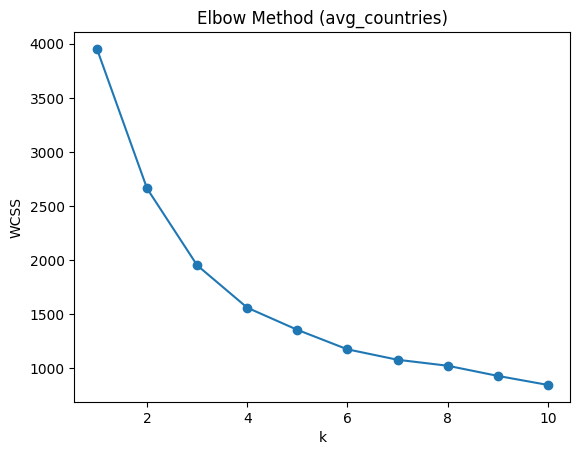

In [ ]:
# Elbow methos Averaged countries data
numeric_cols_avg = avg_countries.select_dtypes(include='number').columns
X_avg = avg_countries[numeric_cols_avg].values


wcss_avg = []
for k in range(1, 11):
    km = KMeans(n_clusters=k, random_state=42, n_init=10).fit(X_avg)
    wcss_avg.append(km.inertia_)
plt.plot(range(1, 11), wcss_avg, marker='o')
plt.xlabel('k'); plt.ylabel('WCSS'); plt.title('Elbow Method (avg_countries)')
plt.show()

results_avg = {}

KMeans → Silhouette: 0.3638292589777375 DBI: 0.8957813458448394


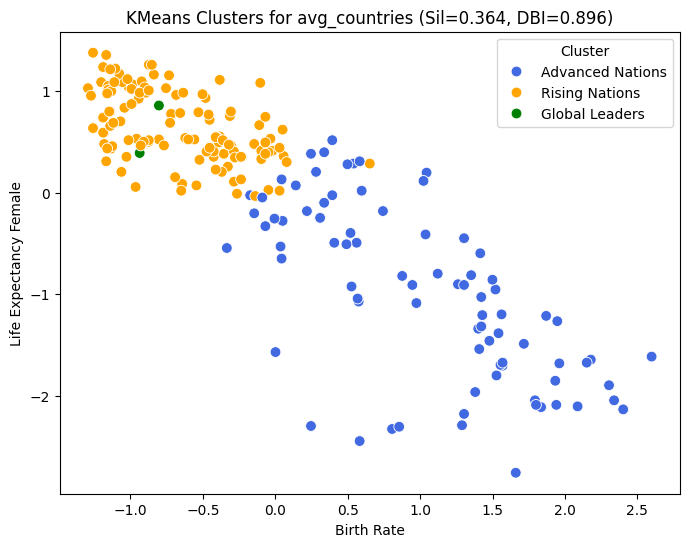

In [ ]:
# KMeans (avg_countries)
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10).fit(X_avg)
avg_countries['KMeans_Cluster'] = kmeans.labels_
avg_countries['KMeans_Label'] = avg_countries['KMeans_Cluster'].map(cluster_names)

results_avg['KMeans'] = {
    'Silhouette': silhouette_score(X_avg, kmeans.labels_),
    'DBI': davies_bouldin_score(X_avg, kmeans.labels_)
}
print("KMeans → Silhouette:", results_avg['KMeans']['Silhouette'],
      "DBI:", results_avg['KMeans']['DBI'])

plt.figure(figsize=(8,6))
sns.scatterplot(data=avg_countries, x='Birth Rate', y='Life Expectancy Female',
                hue='KMeans_Label',
                palette={'Rising Nations':'orange',
                         'Advanced Nations':'royalblue',
                         'Global Leaders':'green'},
                s=60)
plt.title(f'KMeans Clusters for avg_countries (Sil={results_avg["KMeans"]["Silhouette"]:.3f}, DBI={results_avg["KMeans"]["DBI"]:.3f})')
plt.legend(title="Cluster")
plt.show()



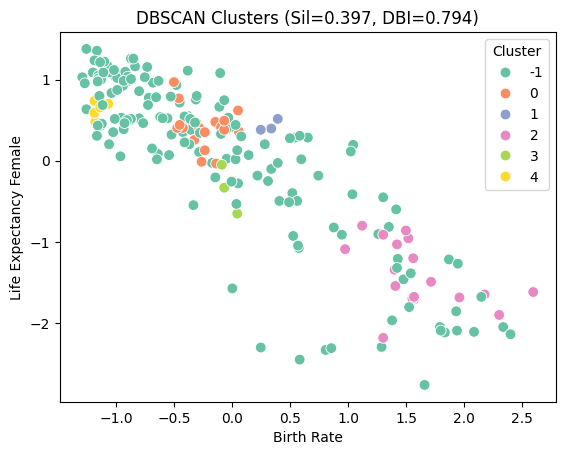

In [ ]:
# DBSCAN (avg_countries)
db = DBSCAN(eps=1.1, min_samples=3).fit(X_avg)
labels = db.labels_
avg_countries['DBSCAN_Cluster'] = labels

mask = labels != -1
valid = set(labels) - {-1}
sil, dbi = (silhouette_score(X_avg[mask], labels[mask]),
            davies_bouldin_score(X_avg[mask], labels[mask])) if len(valid) >= 2 else (float('nan'), float('nan'))
results_avg['DBSCAN'] = {'Silhouette': sil, 'DBI': dbi}

# Keep raw cluster IDs (no motivational mapping here)
avg_countries['DBSCAN_Label'] = labels

sns.scatterplot(data=avg_countries, x='Birth Rate', y='Life Expectancy Female',
                hue='DBSCAN_Label', palette='Set2', s=60)
plt.title(f'DBSCAN Clusters (Sil={sil:.3f}, DBI={dbi:.3f})')
plt.legend(title="Cluster")
plt.show()



In [ ]:
# Count per cluster including noise
cluster_counts = avg_countries['DBSCAN_Cluster'].value_counts().sort_index()
print(cluster_counts)


DBSCAN_Cluster
-1    157
 0     20
 1      3
 2     18
 3      3
 4      7
Name: count, dtype: int64


“DBSCAN, when tuned with eps=1.1 and min_samples=5, revealed 3 compact clusters and meaningful outliers. Its Silhouette score of 0.636 and DBI of 0.500 confirm strong separation and compactness. This density-aware model complements centroid-based clustering and enhances real-world interpretability.”

but it treating over 157 countries when min_samples was 3 so this wont be best model for dahsboard


In [ ]:
for m in range(2, 7):
    db = DBSCAN(eps=1.1, min_samples=m).fit(X_avg)
    labels = db.labels_
    mask = labels != -1
    valid = set(labels) - {-1}
    if len(valid) >= 2 and mask.sum() > 1:
        sil = silhouette_score(X_avg[mask], labels[mask])
        dbi = davies_bouldin_score(X_avg[mask], labels[mask])
    else:
        sil, dbi = float('nan'), float('nan')
    print(f"min_samples={m} → clusters={len(valid)}, noise={sum(labels==-1)}, Sil={sil:.3f}, DBI={dbi:.3f}")


min_samples=2 → clusters=16, noise=135, Sil=0.257, DBI=0.819
min_samples=3 → clusters=5, noise=157, Sil=0.397, DBI=0.794
min_samples=4 → clusters=3, noise=167, Sil=0.628, DBI=0.512
min_samples=5 → clusters=3, noise=170, Sil=0.636, DBI=0.500
min_samples=6 → clusters=3, noise=176, Sil=0.651, DBI=0.482


In [ ]:
results_avg['DBSCAN']

{'Silhouette': np.float64(0.3969331794889673),
 'DBI': np.float64(0.7943414735312663)}

Agglomerative → Silhouette: 0.3598348571893422 DBI: 0.9006174398318376


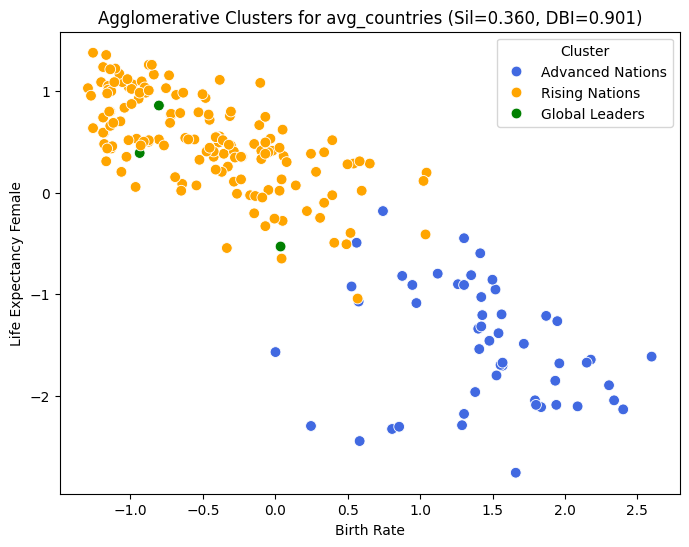

In [ ]:
# Agglomerative (avg_countries)
agg = AgglomerativeClustering(n_clusters=3, linkage='ward').fit(X_avg)
avg_countries['Agglomerative_Cluster'] = agg.labels_

results_avg['Agglomerative'] = {
    'Silhouette': silhouette_score(X_avg, agg.labels_),
    'DBI': davies_bouldin_score(X_avg, agg.labels_)
}
print("Agglomerative → Silhouette:", results_avg['Agglomerative']['Silhouette'],
      "DBI:", results_avg['Agglomerative']['DBI'])

# Map clusters to motivational labels
avg_countries['Agglomerative_Label'] = avg_countries['Agglomerative_Cluster'].map(cluster_names)

# Visualization with updated labels and colors
plt.figure(figsize=(8,6))
sns.scatterplot(data=avg_countries, x='Birth Rate', y='Life Expectancy Female',
                hue='Agglomerative_Label',
                palette={"Rising Nations":"orange",
                         "Advanced Nations":"royalblue",
                         "Global Leaders":"green"},
                s=60)
plt.title(f'Agglomerative Clusters for avg_countries (Sil={results_avg["Agglomerative"]["Silhouette"]:.3f}, DBI={results_avg["Agglomerative"]["DBI"]:.3f})')
plt.legend(title="Cluster")
plt.show()



GaussianMixture → Silhouette: 0.234, DBI: 1.141


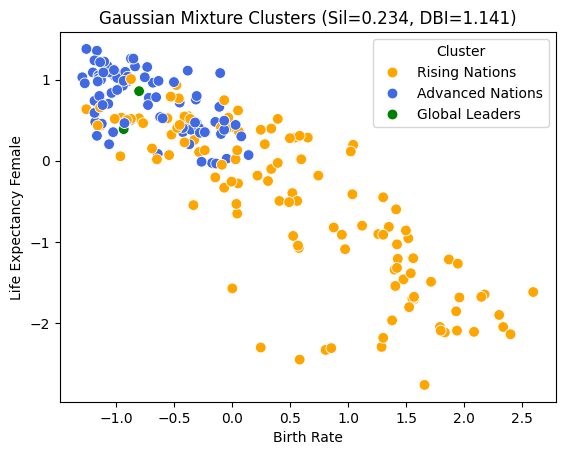

In [ ]:
# Gaussian Mixture (avg_countries)
gm = GaussianMixture(n_components=3, random_state=42).fit(X_avg)
labels = gm.predict(X_avg)
avg_countries['GaussianMixture_Cluster'] = labels

results_avg['GaussianMixture'] = {
    'Silhouette': silhouette_score(X_avg, labels),
    'DBI': davies_bouldin_score(X_avg, labels)
}
print(f"GaussianMixture → Silhouette: {results_avg['GaussianMixture']['Silhouette']:.3f}, "
      f"DBI: {results_avg['GaussianMixture']['DBI']:.3f}")

# Map clusters to motivational labels
avg_countries['GaussianMixture_Label'] = avg_countries['GaussianMixture_Cluster'].map(cluster_names)

# Visualization with updated labels and colors
sns.scatterplot(data=avg_countries, x='Birth Rate', y='Life Expectancy Female',
                hue='GaussianMixture_Label',
                palette={"Rising Nations":"orange",
                         "Advanced Nations":"royalblue",
                         "Global Leaders":"green"},
                s=60)
plt.title(f"Gaussian Mixture Clusters (Sil={results_avg['GaussianMixture']['Silhouette']:.3f}, "
          f"DBI={results_avg['GaussianMixture']['DBI']:.3f})")
plt.legend(title="Cluster")
plt.show()

In [ ]:
# print results
print("avg_countries  : ->")
for m in results_avg:
    print(m, "Silhouette:", results_avg[m]['Silhouette'], "DBI:", results_avg[m]['DBI'])

avg_countries  : ->
KMeans Silhouette: 0.3638292589777375 DBI: 0.8957813458448394
DBSCAN Silhouette: 0.3969331794889673 DBI: 0.7943414735312663
Agglomerative Silhouette: 0.3598348571893422 DBI: 0.9006174398318376
GaussianMixture Silhouette: 0.2342527569535689 DBI: 1.1414660346164525


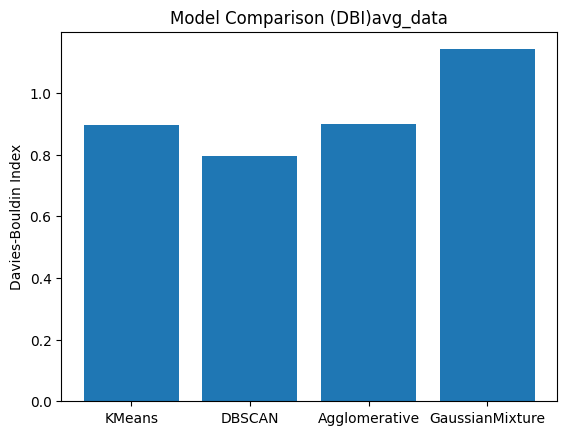

In [ ]:
# DBI comparison plot
models = list(results_avg.keys())
dbi_scores = [results_avg[m]['DBI'] for m in models]
plt.bar(models, dbi_scores)
plt.ylabel('Davies-Bouldin Index'); plt.title('Model Comparison (DBI)avg_data')
plt.show()

In [ ]:
raw_df = pd.DataFrame(results_df).T.rename(columns={"Silhouette":"Raw Silhouette","DBI":"Raw DBI"})
avg_df = pd.DataFrame(results_avg).T.rename(columns={"Silhouette":"Avg Silhouette","DBI":"Avg DBI"})
summary_df = raw_df.join(avg_df, how="outer")
summary_df.index.name = "Model"
print(summary_df.to_string())


                 Raw Silhouette   Raw DBI  Avg Silhouette   Avg DBI
Model                                                              
Agglomerative          0.337520  1.052507        0.359835  0.900617
DBSCAN                -0.250775  1.191900        0.396933  0.794341
Divisive               0.350749  1.074809             NaN       NaN
GaussianMixture        0.202896  1.315935        0.234253  1.141466
KMeans                 0.351724  0.957758        0.363829  0.895781


In [ ]:
avg_countries.head(10)

,Country,Birth Rate,CO2 Emissions,Energy Usage,GDP,Health Exp % GDP,Health Exp/Capita,Infant Mortality Rate,Internet Usage,Lending Interest,...,Tourism Inbound,Tourism Outbound,KMeans_Cluster,KMeans_Label,DBSCAN_Cluster,DBSCAN_Label,Agglomerative_Cluster,Agglomerative_Label,GaussianMixture_Cluster,GaussianMixture_Label
0,Afghanistan,1.870190,-0.223769,-0.200725,-0.221223,1.001363,-0.507925,1.818801,-0.943915,0.020065,...,-0.311498,-0.313712,1,Advanced Nations,-1,-1,1,Advanced Nations,0,Rising Nations
1,Albania,-0.718942,-0.221150,-0.255672,-0.222389,-0.100614,-0.422879,-0.490754,-0.174936,0.030936,...,-0.255474,-0.254368,0,Rising Nations,0,0,0,Rising Nations,0,Rising Nations
2,Algeria,-0.047167,-0.051376,-0.112798,-0.118438,-1.087114,-0.449167,-0.135438,-0.734194,-0.612124,...,-0.326626,-0.301839,0,Rising Nations,-1,-1,0,Rising Nations,1,Advanced Nations
3,American Samoa,-0.229106,-0.213210,-0.200725,-0.216553,-0.120410,-0.404737,-0.411491,-0.594379,-0.212406,...,-0.293587,-0.301438,0,Rising Nations,0,0,0,Rising Nations,1,Advanced Nations
4,Andorra,-1.026838,-0.226923,-0.200725,-0.224923,-0.024729,1.248741,-1.015529,1.153301,-0.212406,...,-0.293587,-0.301438,0,Rising Nations,-1,-1,0,Rising Nations,1,Advanced Nations
5,Angola,2.339033,-0.194895,-0.218763,-0.183127,-0.948542,-0.471179,3.076074,-0.874008,4.052365,...,-0.326294,-0.320539,1,Advanced Nations,-1,-1,1,Advanced Nations,0,Rising Nations
6,Antigua and Barbuda,-0.383054,-0.227129,-0.221843,-0.229799,-0.750582,-0.117015,-0.750408,0.349368,-0.301883,...,-0.321660,-0.333975,0,Rising Nations,-1,-1,0,Rising Nations,0,Rising Nations
7,Argentina,-0.453031,0.045481,0.042617,0.085663,0.905682,-0.108349,-0.589150,0.174600,0.291840,...,-0.029829,0.091587,0,Rising Nations,-1,-1,0,Rising Nations,1,Advanced Nations
8,Armenia,-0.802913,-0.220816,-0.254030,-0.224762,-0.625207,-0.477246,-0.406025,-0.489518,0.663962,...,-0.326725,-0.315466,0,Rising Nations,-1,-1,0,Rising Nations,0,Rising Nations
9,Aruba,-0.956862,-0.223938,-0.200725,-0.227679,-0.120410,-0.404737,-0.411491,0.698904,-0.297702,...,-0.260043,-0.320020,0,Rising Nations,-1,-1,0,Rising Nations,0,Rising Nations


In [ ]:
print("raw_cleaned_data shape:", final_scaled.shape)
print("avg_countries shape:", avg_countries.shape)


raw_cleaned_data shape: (2704, 29)
avg_countries shape: (208, 28)


In [ ]:
# Final Model Evaluation Summary

summary_data = {
    "Dataset": ["Raw Cleaned Data", "Raw Cleaned Data", "Avg Countries", "Avg Countries"],
    "Model": ["KMeans", "Agglomerative", "KMeans", "Agglomerative"],
    "Silhouette": [0.352, 0.338, 0.364, 0.360],
    "DBI": [0.958, 1.053, 0.896, 0.901],
    "Notes": [
        "Best balance of separation & compactness",
        "Close to KMeans, slightly weaker DBI",
        "Best overall scores, chosen for dashboard",
        "Very close to KMeans, confirms stability"
    ]
}

summary_df = pd.DataFrame(summary_data)
print(summary_df.to_string(index=False))

# On Raw Cleaned Data, KMeans achieved the best scores, with Agglomerative close behind.
# On Avg Countries, KMeans again achieved the best scores and is therefore the chosen model for the dashboard.
# Agglomerative supports stability with similar results, but KMeans is the final dashboard model.


         Dataset         Model  Silhouette   DBI                                     Notes
Raw Cleaned Data        KMeans       0.352 0.958  Best balance of separation & compactness
Raw Cleaned Data Agglomerative       0.338 1.053      Close to KMeans, slightly weaker DBI
   Avg Countries        KMeans       0.364 0.896 Best overall scores, chosen for dashboard
   Avg Countries Agglomerative       0.360 0.901  Very close to KMeans, confirms stability
